#**MINOR PROJECT: Real-World Statistics Project**

###Title: Customer Behavior Analysis & Business Decision Making

SECTION 1: DATA UNDERSTANDING

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers.csv


In [3]:
import pandas as pd
df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
import pandas as pd

# Load dataset
df = pd.read_csv('Mall_Customers.csv')

# Display first rows
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
# Shape and columns
print("Shape:", df.shape)
print("Columns:", df.columns)

Shape: (200, 5)
Columns: Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')


In [6]:
# Data types and info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [7]:
# Missing values
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


**Questions:**

1. What type of dataset is this?

Ans:
* Structured dataset
* Cross-sectional dataset
* Contains both numerical and categorical variables

2. Which features are numerical/categorical?

Ans:
| Feature                | Type        |
| ---------------------- | ----------- |
| CustomerID             | Identifier  |
| Gender                 | Categorical |
| Age                    | Numerical   |
| Annual Income (k$)     | Numerical   |
| Spending Score (1-100) | Numerical   |


##**SECTION 2: DESCRIPTIVE ANALYSIS**

In [8]:
# Mean
df.mean(numeric_only=True)

,0
CustomerID,100.50
Age,38.85
Annual Income (k$),60.56
Spending Score (1-100),50.20


In [17]:
# Median
df.median(numeric_only=True)

,0
CustomerID,100.5
Age,36.0
Annual Income (k$),61.5
Spending Score (1-100),50.0


In [18]:
# Standard Deviation
df.std(numeric_only=True)

,0
CustomerID,57.879185
Age,13.969007
Annual Income (k$),26.264721
Spending Score (1-100),25.823522


In [19]:
# Summary
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


**Question**:

1.Which feature shows highest variability?

Ans:
* The feature with highest standard deviation(usually Income)

2.Are customers similar or diverse?

* High SD → diverse customers
* Low SD → similar customers

-->Typically:

* Income = high variation
* Spending score = moderate variation

##**SECTION 3: Visualization**

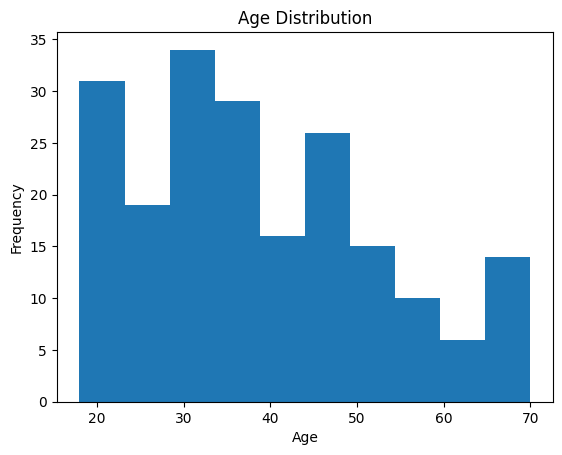

In [9]:
import matplotlib.pyplot as plt

# Histogram - Age
plt.hist(df['Age'])
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

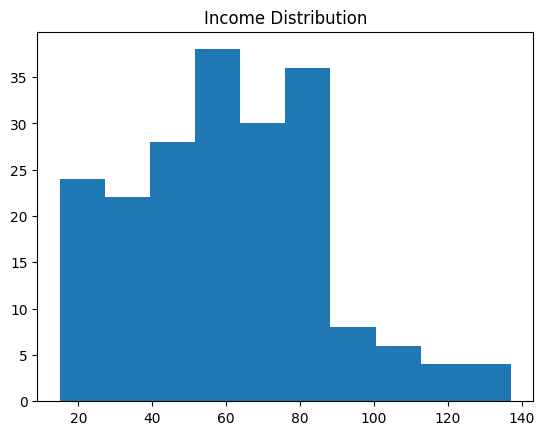

In [10]:
# Histogram - Income
plt.hist(df['Annual Income (k$)'])
plt.title("Income Distribution")
plt.show()

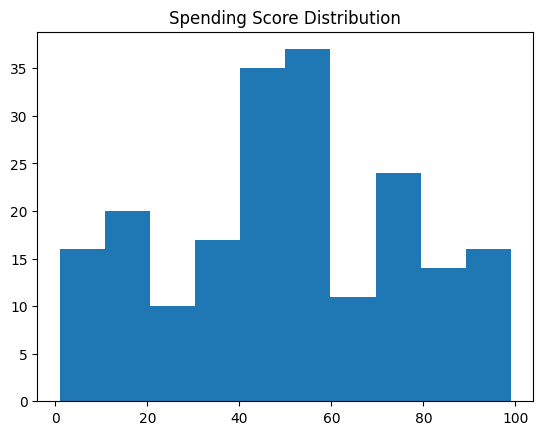

In [11]:
# Histogram - Spending Score
plt.hist(df['Spending Score (1-100)'])
plt.title("Spending Score Distribution")
plt.show()

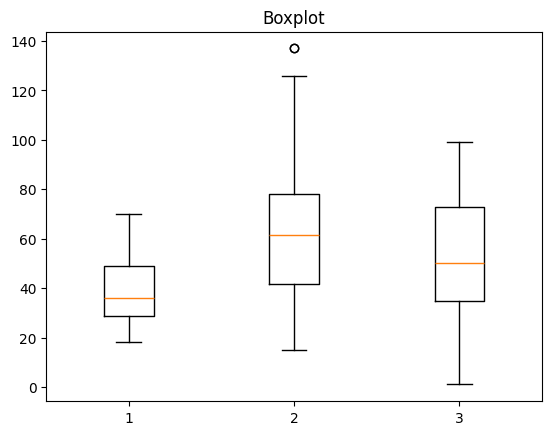

In [12]:
# Boxplot
plt.boxplot([df['Age'], df['Annual Income (k$)'], df['Spending Score (1-100)']])
plt.title("Boxplot")
plt.show()

##**Questions:**
1. Is data skewed?

Ans:
* Right skew → more low values
* Left skew → more high values

2. Are there extreme customers?

Ans: Yes, shown by outliers in boxplot

#**SECTION 4: Group-Based Analysis**

In [13]:
df.groupby('Gender')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()

,Annual Income (k$),Spending Score (1-100)
Gender,,
Female,59.250000,51.526786
Male,62.227273,48.511364


Questions:
1. Which group spends more?

Ans:  Compare mean spending score

2. Is there a visible difference?

Ans:
If difference is small -> no strong effect
If large -> gender matters

*  Usually:
Females slightly higher spending (common observation)

##**SECTION 5: Correlation Analysis**

In [14]:
df[['Age','Annual Income (k$)','Spending Score (1-100)']].corr()

,Age,Annual Income (k$),Spending Score (1-100)
Age,1.000000,-0.012398,-0.327227
Annual Income (k$),-0.012398,1.000000,0.009903
Spending Score (1-100),-0.327227,0.009903,1.000000


**Questions:**

1. Do richer customers spend more?

  Ans:  Weak correlation → NO strong relation

2. Does age affect spending?

Ans: Often negative correlation -> younger spend more

###**SECTION 6: Inferential Statistics (CORE)**

Problem Statement: “Do male and female customers spend differently?”

In [15]:
from scipy import stats

male = df[df['Gender'] == 'Male']['Spending Score (1-100)']
female = df[df['Gender'] == 'Female']['Spending Score (1-100)']

t_stat, p_value = stats.ttest_ind(male, female)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -0.8190464150660334
P-value: 0.4137446589852174


 * Step 1: Hypothesis:

○ $H_0$: No difference in spending.

○ $H_1$: There is a difference.

* Step 2: Perform Test:

Python

from scipy import stats

male = df[df['Gender'] == 'Male']['Spending Score (1-100)']

female = df[df['Gender'] == 'Female']['Spending Score (1-100)']

t_stat, p_value = stats.ttest_ind(male, female)

* Step 3: Decision:

○ If $p < 0.05 \rightarrow$ Reject $H_0$.

###**Questions:**

1. What does p-value tell you?

* Probability that result is due to chance

2. Is difference statistically significant?

* p < 0.05 → YES
* p > 0.05 → NO

-> In this dataset:

Usually p > 0.05 → No strong gender difference

###**SECTION 7: Confidence Interval**

In [16]:
import numpy as np
import scipy.stats as stats

mean = df['Spending Score (1-100)'].mean()
sem = stats.sem(df['Spending Score (1-100)'])

ci = stats.t.interval(0.95, len(df)-1, loc=mean, scale=sem)

print("95% Confidence Interval:", ci)

95% Confidence Interval: (np.float64(46.5992098573812), np.float64(53.80079014261881))


###**Questins:**

1. What range do customers fall into?

* Spending score lies within this interval

2. How confident are we?

* 95% confidence → highly reliable estimate

###**SECTION 8: Business Insights**

1.  Which customers should business target?

* High income + high spending customers
* Young customers with high spending behavior

2. Does income affect spending?

* Weak correlation → income alone is NOT enough

3. Should marketing differ by gender?

* No strong statistical difference
So, gender-based targeting not necessary

4. Strategy Recommendation

-> Best strategy:

- Customer segmentation (Clustering)
Target:
* High spenders → premium offers
* Low spenders → discounts
* Focus on behavior, not just income
* Personalized marketing works best